# Market Simulation

## Libraries Import

In [59]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy import stats
from scipy.optimize import brentq

sys.path.append('..')
from src.config_loader import load_config
from src.stochastic_engines import GBMModel, MertonJumpDiffusion
from src.analytics import bsm_price

config = load_config()

config.market = config.market_params
config.merton = config.merton_params
config.sim = config.simulation

## Path Generation

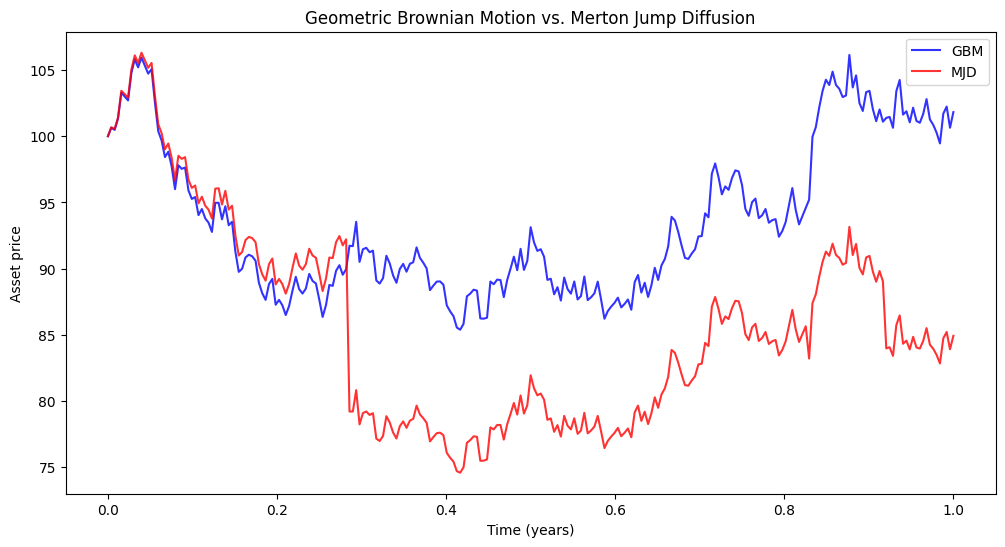

In [60]:
gbm = GBMModel(config).generate_paths()
merton = MertonJumpDiffusion(config).generate_paths()

# Time grid
n_steps = gbm.shape[1] - 1
T = config.market.T
_t = np.linspace(0.0, T, n_steps + 1)

plt.figure(figsize=(12, 6))
plt.plot(_t, gbm[0, :], label='GBM', color='blue', alpha=0.8)
plt.plot(_t, merton[0, :], label='MJD', color='red', alpha=0.8)
plt.title("Geometric Brownian Motion vs. Merton Jump Diffusion")
plt.xlabel("Time (years)")
plt.ylabel("Asset price")
plt.legend()
plt.show()

## Monte Carlo Simulation

In [61]:
# Time grid
n_steps = gbm.shape[1] - 1
t = np.arange(n_steps + 1) * config.market.dt

# Functions
def sample_paths(paths: np.ndarray, n_plot: int = 30, seed: int = 123) -> np.ndarray:
    rng = np.random.default_rng(seed)
    n = paths.shape[0]
    idx = rng.choice(n, size=min(n_plot, n), replace=False)
    return paths[idx]


def log_returns(paths: np.ndarray) -> np.ndarray:
    return np.diff(np.log(paths), axis=1)


def terminal_log_returns(paths: np.ndarray) -> np.ndarray:
    return np.log(paths[:, -1] / paths[:, 0])


def var_cvar(x: np.ndarray, alpha: float = 0.99) -> tuple[float, float]:
    x = np.asarray(x)
    q = np.quantile(x, alpha)
    tail = x[x >= q]
    cvar = float(tail.mean()) if tail.size else float("nan")
    return float(q), cvar


def max_drawdown(paths: np.ndarray) -> np.ndarray:
    running_max = np.maximum.accumulate(paths, axis=1)
    dd = 1.0 - (paths / running_max)
    return dd.max(axis=1)


def realized_variance(r: np.ndarray) -> np.ndarray:
    return np.sum(r**2, axis=1)


def bipower_variation(r: np.ndarray) -> np.ndarray:
    abs_r = np.abs(r)
    return (np.pi / 2.0) * np.sum(abs_r[:, 1:] * abs_r[:, :-1], axis=1)


def implied_vol_from_price(price: float, S: float, K: float, T: float, r: float, option_type: str = 'call') -> float:
    if price <= 0:
        return float('nan')

    def f(sig: float) -> float:
        return bsm_price(S, K, T, r, sig, option_type=option_type) - price

    try:
        return float(brentq(f, 1e-6, 5.0, maxiter=200))
    except ValueError:
        return float('nan')


print(f"n_paths={gbm.shape[0]}, n_steps={n_steps}, dt={config.market.dt}, T≈{n_steps*config.market.dt:.4f}")

n_paths=10000, n_steps=252, dt=0.003968, T≈0.9999


## Path Diagnostics

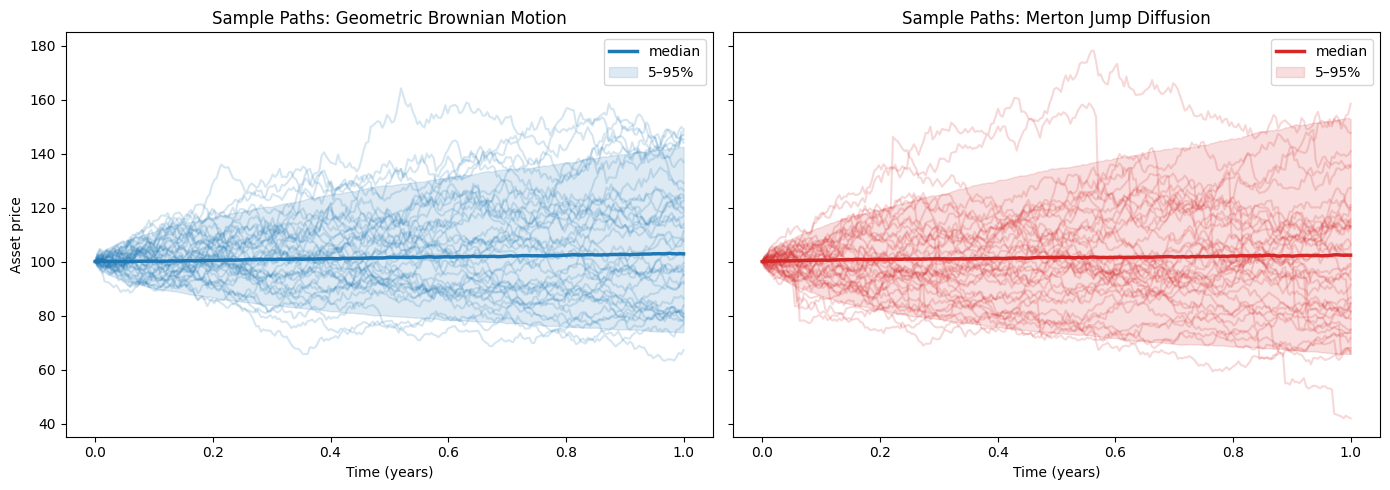

In [62]:
n_plot = 40

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# GBM sample paths
for p in sample_paths(gbm, n_plot=n_plot, seed=config.sim.seed + 1):
    axes[0].plot(t, p, color='tab:blue', alpha=0.18)

q05, q50, q95 = np.quantile(gbm, [0.05, 0.5, 0.95], axis=0)
axes[0].plot(t, q50, color='tab:blue', lw=2.5, label='median')
axes[0].fill_between(t, q05, q95, color='tab:blue', alpha=0.15, label='5–95%')
axes[0].set_title('Sample Paths: Geometric Brownian Motion')
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Asset price')
axes[0].legend()

# MJD sample paths
for p in sample_paths(merton, n_plot=n_plot, seed=config.sim.seed + 2):
    axes[1].plot(t, p, color='tab:red', alpha=0.18)

q05, q50, q95 = np.quantile(merton, [0.05, 0.5, 0.95], axis=0)
axes[1].plot(t, q50, color='tab:red', lw=2.5, label='median')
axes[1].fill_between(t, q05, q95, color='tab:red', alpha=0.15, label='5–95%')
axes[1].set_title('Sample Paths: Merton Jump Diffusion')
axes[1].set_xlabel('Time (years)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Statistics Summary

In [63]:
def describe_returns(r_flat: np.ndarray) -> dict:
    return {
        'std': float(np.std(r_flat, ddof=1)),
        'mean': float(np.mean(r_flat)),
        'skew': float(stats.skew(r_flat)),
        'kurtosis': float(stats.kurtosis(r_flat, fisher=True)),
    }

# Daily returns
daily_stats = pd.DataFrame({
    'GBM': describe_returns(r_g),
    'MJD': describe_returns(r_m),
})

# Terminal returns
gbm_T = terminal_log_returns(gbm)
merton_T = terminal_log_returns(merton)
terminal_stats = pd.DataFrame({
    'GBM': describe_returns(gbm_T),
    'MJD': describe_returns(merton_T),
})

print('Daily log-return stats')
display(daily_stats)

print('Terminal log-return stats')
display(terminal_stats)

Daily log-return stats


,GBM,MJD
std,0.012608,0.016098
mean,0.000113,0.000067
skew,-0.000581,-3.053617
kurtosis,-0.000204,55.007797


Terminal log-return stats


,GBM,MJD
std,0.198221,0.255374
mean,0.028531,0.016980
skew,-0.027703,-0.198550
kurtosis,0.068272,0.299765


## Maximum Drawdown Distribution

,mean_terminal_return,std_terminal_return,mean_max_drawdown,p95_max_drawdown,VaR_95,CVaR_95,VaR_99,CVaR_99
model,,,,,,,,
GBM,0.028531,0.198221,0.197618,0.339738,0.303791,0.386806,0.434572,0.503271
Merton,0.016980,0.255374,0.237385,0.427678,0.418255,0.545681,0.621694,0.741361


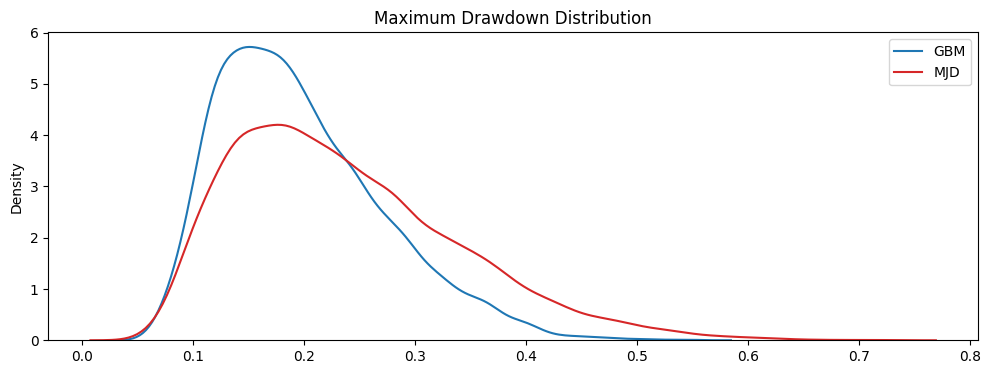

In [64]:
alphas = [0.95, 0.99]

rows = []
for name, rT in [('GBM', gbm_T), ('Merton', merton_T)]:
    losses = -rT
    mdd = max_drawdown(gbm if name == 'GBM' else merton)
    row = {
        'model': name,
        'mean_terminal_return': float(rT.mean()),
        'std_terminal_return': float(rT.std(ddof=1)),
        'mean_max_drawdown': float(mdd.mean()),
        'p95_max_drawdown': float(np.quantile(mdd, 0.95)),
    }
    for a in alphas:
        v, c = var_cvar(losses, alpha=a)
        row[f'VaR_{int(a*100)}'] = v
        row[f'CVaR_{int(a*100)}'] = c
    rows.append(row)

df_risk = pd.DataFrame(rows).set_index('model')
display(df_risk)

plt.figure(figsize=(12, 4))
sns.kdeplot(max_drawdown(gbm), label='GBM', color='tab:blue')
sns.kdeplot(max_drawdown(merton), label='MJD', color='tab:red')
plt.title('Maximum Drawdown Distribution')
plt.legend()
plt.show()